In [1]:
# Cell 0 — Mount Google Drive and extract dataset
# ── Step 1: Run on your LOCAL machine ──
# cd /Users/BAEK/Code/gaitkeeper
# zip -r data_processed.zip data_processed/
#
# ── Step 2: Upload data_processed.zip to MyDrive/Colab/ in Google Drive ──
# ── Step 3: Run cells top to bottom ──

from google.colab import drive
import zipfile, os

drive.mount('/content/drive')

ZIP_PATH = '/content/drive/MyDrive/Colab/data_processed.zip'

if not os.path.exists('/content/data_processed'):
    print('Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/')
    print('Done.')
else:
    print('Dataset already extracted.')

Mounted at /content/drive
Extracting dataset...
Done.


In [2]:
# Cell 1 — Installs
!pip install ultralytics kornia --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 102.6 MB/s eta 0:00:00


In [3]:
# Cell 2 — Imports
import cv2
import random
import numpy as np
import torch
import torch.nn.functional as F
import kornia
import kornia.augmentation as K
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Cell 3 — Config
# ── Training ──────────────────────────────────────────
PATCH_H          = 200
PATCH_W          = 150
PATCH_SCALE      = 0.5
SHIRT_TOP        = 0.20   # same as V8 — top of shirt region
SHIRT_BOT        = 0.48   # unchanged — torso only, no groin
EPSILON          = 1.0
LR               = 0.005
NUM_STEPS        = 1200   # was 800 — model still improving at step 800, no plateau
EOT_N            = 6
TOP_K            = 5      # was 30 — concentrate gradient on single max-conf anchor + 4 neighbors

# ── Loss weights ──────────────────────────────────────
# V9 changes:
#   - SHIRT_TOP kept at 0.20: same patch location as V8
#   - TOP_K 30→5: concentrate BCE gradient on single highest anchor instead of diluting over 30
#   - box_disruption_loss clamped at 250 before norm: kills spike steps (steps 400,450,650 in V8)
#   - NUM_STEPS 800→1200, CURRICULUM_STEPS 200→300: more training, longer single-image phase
BOX_NORM         = 20.0
SUPPRESS_LOSS_W  = 0.4
BOX_LOSS_W       = 0.4
MASK_LOSS_W      = 0.2

# ── Curriculum / blended training ─────────────────────
CURRICULUM_STEPS = 300    # was 200
BLEND_EVAL_PROB  = 0.4

# ── Dataset ────────────────────────────────────────────
USE_CACHED_SAMPLES = True

# ── Paths ──────────────────────────────────────────────
DRIVE_DIR        = '/content/drive/MyDrive/Colab'
IMAGE_PATH       = f'{DRIVE_DIR}/person.jpg'
VIDEO_DIR        = '/content/data_processed'
FRAMES_PER_VIDEO = 10
SAMPLES_PATH     = f'{DRIVE_DIR}/training_samples.pkl'

# ── Model ──────────────────────────────────────────────
YOLO_MODEL = 'yolov8n-seg'
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


In [5]:
# Cell 4 — Load YOLOv8-seg, freeze weights
yolo = YOLO(YOLO_MODEL)
torch_model = yolo.model.to(DEVICE)
torch_model.eval()

for p in torch_model.parameters():
    p.requires_grad_(False)

print(f'Model loaded: {YOLO_MODEL} | Parameters frozen: {sum(p.numel() for p in torch_model.parameters()):,}')

Model loaded: yolov8n-seg | Parameters frozen: 3,409,968


In [6]:
# Cell 5 — Forward pass helpers
def yolo_raw_forward(img_tensor):
    out = torch_model(img_tensor)
    return {'preds': out[0][0], 'proto': out[0][1]}

def img_to_tensor(img_np):
    """uint8 HxWx3 BGR numpy → [1, 3, 640, 640] float32 tensor on DEVICE"""
    img = cv2.resize(img_np, (640, 640))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    return t.unsqueeze(0).to(DEVICE)

In [7]:
# Cell 6 — Shirt detection and patch placement
def detect_shirt_region(img_np):
    """
    Returns (shirt_box_img, shirt_box_mask) in 640x640 and 160x160 coords.
    Returns (None, None) if no person detected.
    """
    with torch.no_grad():
        results = yolo(cv2.resize(img_np, (640, 640)), verbose=False)

    if not results or results[0].boxes is None or len(results[0].boxes) == 0:
        return None, None

    boxes = results[0].boxes
    person_mask = (boxes.cls == 0)
    if not person_mask.any():
        return None, None

    best_idx = boxes.conf[person_mask].argmax()
    x1, y1, x2, y2 = boxes.xyxy[person_mask][best_idx].cpu().numpy()

    h, w = y2 - y1, x2 - x1
    cx = (x1 + x2) / 2
    half_w = w * PATCH_SCALE / 2
    sx1 = int(cx - half_w)
    sy1 = int(y1 + h * SHIRT_TOP)
    sx2 = int(cx + half_w)
    sy2 = int(y1 + h * SHIRT_BOT)

    scale = 160 / 640
    mx1 = max(0, int(sx1 * scale))
    my1 = max(0, int(sy1 * scale))
    mx2 = min(159, int(sx2 * scale))
    my2 = min(159, int(sy2 * scale))

    if mx2 <= mx1 or my2 <= my1:
        return None, None

    return (sx1, sy1, sx2, sy2), (mx1, my1, mx2, my2)


def paste_patch(img_tensor, patch, shirt_box):
    """Paste patch into img_tensor at shirt_box, preserving gradient through patch."""
    x1, y1, x2, y2 = [int(v) for v in shirt_box]
    w, h = x2 - x1, y2 - y1
    if w <= 0 or h <= 0:
        return img_tensor
    patch_resized = F.interpolate(patch, size=(h, w), mode='bilinear', align_corners=False)
    patched = img_tensor.clone()
    patched[:, :, y1:y2, x1:x2] = patch_resized
    return patched

In [8]:
# Cell 7 — Loss functions
#
# V9 changes over V8:
#   1. person_suppress_loss: TOP_K 30→5 — concentrate BCE on max-confidence anchor.
#      Averaging 30 anchors dilutes gradient; 5 anchors hit the single anchor
#      that actually drives the detection with full force.
#   2. box_disruption_loss: clamp raw wh at 250 before dividing by BOX_NORM.
#      Prevents loss spikes from large-person training samples (V8 steps 400,450,650
#      jumped to 12-16x normal — one bad sample pulling the patch off-track).

def build_anchor_grid():
    strides, grids = [8, 16, 32], [80, 40, 20]
    cx_list, cy_list, stride_list = [], [], []
    for stride, g in zip(strides, grids):
        xs = (torch.arange(g, device=DEVICE) + 0.5) * stride
        ys = (torch.arange(g, device=DEVICE) + 0.5) * stride
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')
        cx_list.append(xx.reshape(-1))
        cy_list.append(yy.reshape(-1))
        stride_list.append(torch.full((g * g,), stride, device=DEVICE))
    return torch.cat(cx_list), torch.cat(cy_list), torch.cat(stride_list)

ANCHOR_CX, ANCHOR_CY, ANCHOR_STRIDE = build_anchor_grid()
COARSE_MASK = (ANCHOR_STRIDE >= 16)


def person_suppress_loss(raw):
    """
    BCE loss on the TOP_K=5 highest-confidence coarse anchors.
    Concentrating on 5 (vs 30) gives the optimizer a sharper, less diluted
    gradient signal toward the anchor actually driving the detection.
    """
    person_conf = torch.sigmoid(raw['preds'][0, 4, :])
    coarse      = person_conf[COARSE_MASK]
    topk_idx    = coarse.topk(TOP_K, largest=True).indices
    targets     = torch.zeros(TOP_K, device=DEVICE)
    return F.binary_cross_entropy(coarse[topk_idx], targets)


def box_disruption_loss(raw):
    """
    Minimize predicted w/h of top-K person anchors.
    Clamped at 250 before normalization to kill outlier spikes from large-person
    training samples (V8 showed spikes of 12-16x normal box values).
    """
    preds        = raw['preds']
    person_conf  = torch.sigmoid(preds[0, 4, :])
    topk_idx     = person_conf[COARSE_MASK].topk(TOP_K, largest=True).indices
    coarse_boxes = preds[0, 2:4, :][:, COARSE_MASK]
    wh           = coarse_boxes[:, topk_idx]
    return wh.mean().clamp(max=250) / BOX_NORM


def mask_suppression_loss(raw, patch_box_mask):
    """Minimize mask probability in the patch region."""
    preds = raw['preds']
    proto = raw['proto']

    person_conf = torch.sigmoid(preds[0, 4, :])
    best        = person_conf.argmax()

    if person_conf[best].item() < 0.05:
        return preds[0, 84:, 0].sum() * 0.0

    mask_coeff  = preds[0, 84:, best]
    proto_flat  = proto[0].reshape(32, -1)
    mask_logits = (mask_coeff @ proto_flat).reshape(160, 160)
    mask_prob   = torch.sigmoid(mask_logits)

    x1, y1, x2, y2 = patch_box_mask
    patch_region = mask_prob[y1:y2, x1:x2]
    if patch_region.numel() == 0:
        return preds[0, 84:, 0].sum() * 0.0
    return patch_region.mean()


def combined_loss(raw, patch_box_img, patch_box_mask):
    s_loss = person_suppress_loss(raw)
    b_loss = box_disruption_loss(raw)
    m_loss = mask_suppression_loss(raw, patch_box_mask)
    return SUPPRESS_LOSS_W * s_loss + BOX_LOSS_W * b_loss + MASK_LOSS_W * m_loss

In [9]:
# Cell 8 — Differentiable EoT transforms via kornia
def apply_eot_transforms(patch):
    """patch: [1, 3, H, W] — returns augmented patch, gradient preserved."""
    p = patch

    if random.random() < 0.5:
        p = (p * random.uniform(0.6, 1.4)).clamp(0, 1)

    if random.random() < 0.5:
        p = K.ColorJitter(hue=0.1, saturation=0.1, p=1.0)(p)

    if random.random() < 0.5:
        angle = torch.tensor([random.uniform(-15, 15)], device=DEVICE)
        p = kornia.geometry.rotate(p, angle)

    if random.random() < 0.5:
        p = K.RandomPerspective(distortion_scale=0.2, p=1.0)(p)

    if random.random() < 0.5:
        ksize = random.choice([3, 5, 7])
        p = kornia.filters.motion_blur(p, kernel_size=ksize,
                                       angle=random.uniform(0, 360), direction=0.0)

    if random.random() < 0.5:
        p = p + torch.randn_like(p) * random.uniform(0, 10) / 255.0

    return p.clamp(0, 1)

In [10]:
# Cell 9 — Load or build training dataset
import pickle
from glob import glob

if USE_CACHED_SAMPLES:
    with open(SAMPLES_PATH, 'rb') as f:
        training_samples = pickle.load(f)
    print(f'Loaded {len(training_samples)} samples from {SAMPLES_PATH}')
else:
    def sample_frames_from_video(video_path, n_frames):
        cap = cv2.VideoCapture(video_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release()
            return []
        indices = [int(i * total / n_frames) for i in range(n_frames)]
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frames.append(frame)
        cap.release()
        return frames

    video_paths = glob(f'{VIDEO_DIR}/**/*.mp4', recursive=True)
    print(f'Found {len(video_paths)} videos. Extracting frames...')

    training_samples = []
    for vp in sorted(video_paths):
        frames = sample_frames_from_video(vp, FRAMES_PER_VIDEO)
        valid = 0
        for frame in frames:
            b_img, b_mask = detect_shirt_region(frame)
            if b_img is not None:
                training_samples.append((frame, b_img, b_mask))
                valid += 1
        print(f'  {Path(vp).name}: {valid}/{len(frames)} frames detected')

    with open(SAMPLES_PATH, 'wb') as f:
        pickle.dump(training_samples, f)
    print(f'\nSaved {len(training_samples)} samples to {SAMPLES_PATH}')

print(f'Total training samples: {len(training_samples)}')

Loaded 280 samples from /content/drive/MyDrive/Colab/training_samples.pkl
Total training samples: 280


In [11]:
# Cell 10 — Initialize patch + baseline
img_eval = cv2.imread(IMAGE_PATH)
if img_eval is None:
    raise FileNotFoundError(f'Could not load {IMAGE_PATH}')

with torch.no_grad():
    raw_baseline = yolo_raw_forward(img_to_tensor(img_eval))
    box_eval_img, box_eval_mask = detect_shirt_region(img_eval)
    baseline_conf = torch.sigmoid(raw_baseline['preds'][0, 4, :])[COARSE_MASK].topk(TOP_K).values.mean().item()

print(f'Baseline person conf in patch region: {baseline_conf:.4f}')

torch.manual_seed(42)
patch = torch.empty(1, 3, PATCH_H, PATCH_W, device=DEVICE).uniform_(0.4, 0.6)
patch.requires_grad_(True)
patch_init = patch.data.clone()

optimizer = torch.optim.Adam([patch], lr=LR)
print(f'Patch initialized: {list(patch.shape)}')

Baseline person conf in patch region: 0.7101
Patch initialized: [1, 3, 200, 150]


In [12]:
# Cell 11 — Training loop (V9: curriculum + blended phase 2)
#
# Phase 1 (0 → CURRICULUM_STEPS-1): eval image only — find adversarial direction
# Phase 2 (CURRICULUM_STEPS → end): BLENDED — 40% eval image + 60% dataset
#   V5 hard-switched to 100% dataset at step 200, causing catastrophic forgetting
#   (loss jumped from 0.04 back to 0.20). Blending keeps the eval signal alive.

if not training_samples:
    raise RuntimeError('No training samples — run Cell 9 first')

eval_sample       = (img_eval, box_eval_img, box_eval_mask)
loss_history      = []
suppress_history  = []
box_history       = []
mask_history      = []
phase_switch_step = None

for step in range(NUM_STEPS):
    optimizer.zero_grad()

    if step < CURRICULUM_STEPS:
        img, box_img, box_mask = eval_sample
    else:
        if phase_switch_step is None:
            phase_switch_step = step
            print(f'Step {step}: switching to blended training '
                  f'({BLEND_EVAL_PROB:.0%} eval / {1-BLEND_EVAL_PROB:.0%} dataset)')
        if random.random() < BLEND_EVAL_PROB:
            img, box_img, box_mask = eval_sample
        else:
            img, box_img, box_mask = random.choice(training_samples)

    img_tensor = img_to_tensor(img)

    step_loss = 0.0
    step_mclass = step_box = step_mask = 0.0
    for _ in range(EOT_N):
        aug_patch = apply_eot_transforms(patch)
        patched   = paste_patch(img_tensor, aug_patch, box_img)
        raw       = yolo_raw_forward(patched)

        ml = person_suppress_loss(raw)
        bl = box_disruption_loss(raw)
        sl = mask_suppression_loss(raw, box_mask)
        loss = (SUPPRESS_LOSS_W * ml + BOX_LOSS_W * bl + MASK_LOSS_W * sl) / EOT_N
        loss.backward()

        step_loss   += loss.item()
        step_mclass += ml.item() / EOT_N
        step_box    += bl.item() / EOT_N
        step_mask   += sl.item() / EOT_N

    optimizer.step()

    with torch.no_grad():
        delta = (patch.data - patch_init).clamp(-EPSILON, EPSILON)
        patch.data = (patch_init + delta).clamp(0, 1)

    loss_history.append(step_loss)
    suppress_history.append(step_mclass)
    box_history.append(step_box)
    mask_history.append(step_mask)

    if step % 50 == 0:
        delta_stats = (patch.data - patch_init)
        phase = 'curriculum' if step < CURRICULUM_STEPS else 'blended'
        print(f'Step {step:3d}/{NUM_STEPS} | loss {step_loss:.4f} '
              f'[suppress {step_mclass:.4f} | box {step_box:.4f} | mask {step_mask:.4f}] '
              f'| Δpatch mean {delta_stats.mean().item():+.4f} max {delta_stats.abs().max().item():.4f} '
              f'| {phase}')

print('Training complete.')

Step   0/1200 | loss 5.2423 [suppress 1.2213 | box 11.4348 | mask 0.8995] | Δpatch mean -0.0000 max 0.0050 | curriculum
Step  50/1200 | loss 5.0020 [suppress 1.1947 | box 11.2350 | mask 0.1504] | Δpatch mean -0.0006 max 0.2246 | curriculum
Step 100/1200 | loss 4.8586 [suppress 1.1633 | box 10.9426 | mask 0.0814] | Δpatch mean -0.0013 max 0.3575 | curriculum
Step 150/1200 | loss 4.7410 [suppress 1.1549 | box 10.6603 | mask 0.0748] | Δpatch mean -0.0024 max 0.5064 | curriculum
Step 200/1200 | loss 4.7518 [suppress 1.1608 | box 10.6831 | mask 0.0715] | Δpatch mean -0.0036 max 0.5428 | curriculum
Step 250/1200 | loss 4.7196 [suppress 1.1562 | box 10.5916 | mask 0.1023] | Δpatch mean -0.0050 max 0.5959 | curriculum
Step 300: switching to blended training (40% eval / 60% dataset)
Step 300/1200 | loss 3.3707 [suppress 0.8510 | box 7.2496 | mask 0.6520] | Δpatch mean -0.0065 max 0.5993 | blended
Step 350/1200 | loss 5.4939 [suppress 1.0867 | box 12.5000 | mask 0.2961] | Δpatch mean -0.0078 max

In [13]:
# Cell 12 — Evaluation metrics
img_eval        = cv2.imread(IMAGE_PATH)
img_eval_640    = cv2.resize(img_eval, (640, 640))
img_tensor_eval = img_to_tensor(img_eval)
box_eval_img, box_eval_mask = detect_shirt_region(img_eval)

patch_np = patch.detach().cpu().squeeze().permute(1, 2, 0).numpy()
patch_np = (patch_np * 255).astype(np.uint8)

x1, y1, x2, y2 = box_eval_img
img_patched_np = img_eval_640.copy()
img_patched_np[y1:y2, x1:x2] = cv2.cvtColor(
    cv2.resize(patch_np, (x2 - x1, y2 - y1)), cv2.COLOR_RGB2BGR
)

with torch.no_grad():
    raw_clean   = yolo_raw_forward(img_tensor_eval)
    patched_t   = paste_patch(img_tensor_eval, patch, box_eval_img)
    raw_patched = yolo_raw_forward(patched_t)

    clean_mclass   = person_suppress_loss(raw_clean).item()
    patched_mclass = person_suppress_loss(raw_patched).item()
    clean_box      = box_disruption_loss(raw_clean).item()
    patched_box    = box_disruption_loss(raw_patched).item()
    clean_mask     = mask_suppression_loss(raw_clean,   box_eval_mask).item()
    patched_mask   = mask_suppression_loss(raw_patched, box_eval_mask).item()

    # Per-anchor person confidence stats — clean vs patched
    clean_all_conf   = torch.sigmoid(raw_clean['preds'][0, 4, :])
    patched_all_conf = torch.sigmoid(raw_patched['preds'][0, 4, :])

    # Coarse top-K (our training target)
    clean_topk   = clean_all_conf[COARSE_MASK].topk(TOP_K).values
    patched_topk = patched_all_conf[COARSE_MASK].topk(TOP_K).values

    # Target class (sports ball) confidence

results_clean_eval   = yolo(img_eval_640,   verbose=False)
results_patched_eval = yolo(img_patched_np, verbose=False)

def best_person_conf(results):
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None
    m = (boxes.cls == 0)
    return boxes.conf[m].max().item() if m.any() else None

yolo_clean   = best_person_conf(results_clean_eval)
yolo_patched = best_person_conf(results_patched_eval)

def pct(a, b):
    return (a - (b or 0)) / (a + 1e-9) * 100

# ── Print results ──────────────────────────────────────────────────────────────
print('═' * 62)
print('  LOSS COMPONENTS')
print('─' * 62)
print(f'  {"Metric":<38} {"Clean":>7}  {"Patched":>8}')
print('─' * 62)
print(f'  {"Person suppress (BCE)":<38} {clean_mclass:>7.4f}  {patched_mclass:>8.4f}')
print(f'  {"Box disruption (w/h raw mean)":<38} {clean_box:>7.4f}  {patched_box:>8.4f}  ({pct(clean_box,patched_box):+.1f}%)')
print(f'  {"Mask prob in patch region":<38} {clean_mask:>7.4f}  {patched_mask:>8.4f}  ({pct(clean_mask,patched_mask):+.1f}%)')

print()
print('  ANCHOR-LEVEL PERSON CONFIDENCE (coarse top-K)')
print('─' * 62)
print(f'  {"Top-K mean":<38} {clean_topk.mean().item():>7.4f}  {patched_topk.mean().item():>8.4f}  ({pct(clean_topk.mean().item(), patched_topk.mean().item()):+.1f}%)')
print(f'  {"Top-K max":<38} {clean_topk.max().item():>7.4f}  {patched_topk.max().item():>8.4f}  ({pct(clean_topk.max().item(), patched_topk.max().item()):+.1f}%)')
print(f'  {"Top-K min":<38} {clean_topk.min().item():>7.4f}  {patched_topk.min().item():>8.4f}  ({pct(clean_topk.min().item(), patched_topk.min().item()):+.1f}%)')
print(f'  {"Global max (all 8400)":<38} {clean_all_conf.max().item():>7.4f}  {patched_all_conf.max().item():>8.4f}  ({pct(clean_all_conf.max().item(), patched_all_conf.max().item()):+.1f}%)')
print(f'  {"Global mean (all 8400)":<38} {clean_all_conf.mean().item():>7.4f}  {patched_all_conf.mean().item():>8.4f}')

print()
print('  YOLO HIGH-LEVEL OUTPUT (post-NMS)')
print('─' * 62)
if yolo_clean is not None:
    patched_str = f'{yolo_patched:.4f}' if yolo_patched else 'NO DETECT'
    print(f'  {"Best person detection conf":<38} {yolo_clean:>7.4f}  {patched_str:>8}  ({pct(yolo_clean, yolo_patched):+.1f}%)')
# All detections in patched image
print(f'  All detections (patched image):')
if results_patched_eval[0].boxes is not None:
    COCO_NAMES = yolo.names
    for cls_id, conf in zip(results_patched_eval[0].boxes.cls, results_patched_eval[0].boxes.conf):
        print(f'    {COCO_NAMES[int(cls_id)]:<20} conf={conf.item():.4f}')
else:
    print('    (none)')

print()
print('  PATCH STATISTICS')
print('─' * 62)
delta = (patch.data - patch_init)
print(f'  {"Δ mean":<38} {delta.mean().item():>+.4f}')
print(f'  {"Δ std":<38} {delta.std().item():>.4f}')
print(f'  {"Δ max abs":<38} {delta.abs().max().item():>.4f}  (EPSILON={EPSILON})')
print(f'  {"% pixels at epsilon boundary":<38} {((delta.abs() > EPSILON*0.99).float().mean().item()*100):>.1f}%')
print(f'  {"Patch pixel mean":<38} {patch.data.mean().item():>.4f}')
print(f'  {"Patch pixel std":<38} {patch.data.std().item():>.4f}')
print('═' * 62)

══════════════════════════════════════════════════════════════
  LOSS COMPONENTS
──────────────────────────────────────────────────────────────
  Metric                                   Clean   Patched
──────────────────────────────────────────────────────────────
  Person suppress (BCE)                   1.2382    1.0528
  Box disruption (w/h raw mean)          11.3691    9.1160  (+19.8%)
  Mask prob in patch region               0.9985    0.0325  (+96.7%)

  ANCHOR-LEVEL PERSON CONFIDENCE (coarse top-K)
──────────────────────────────────────────────────────────────
  Top-K mean                              0.7101    0.6509  (+8.3%)
  Top-K max                               0.7117    0.6693  (+6.0%)
  Top-K min                               0.7086    0.6405  (+9.6%)
  Global max (all 8400)                   0.7117    0.6693  (+6.0%)
  Global mean (all 8400)                  0.5002    0.5003

  YOLO HIGH-LEVEL OUTPUT (post-NMS)
─────────────────────────────────────────────────────────

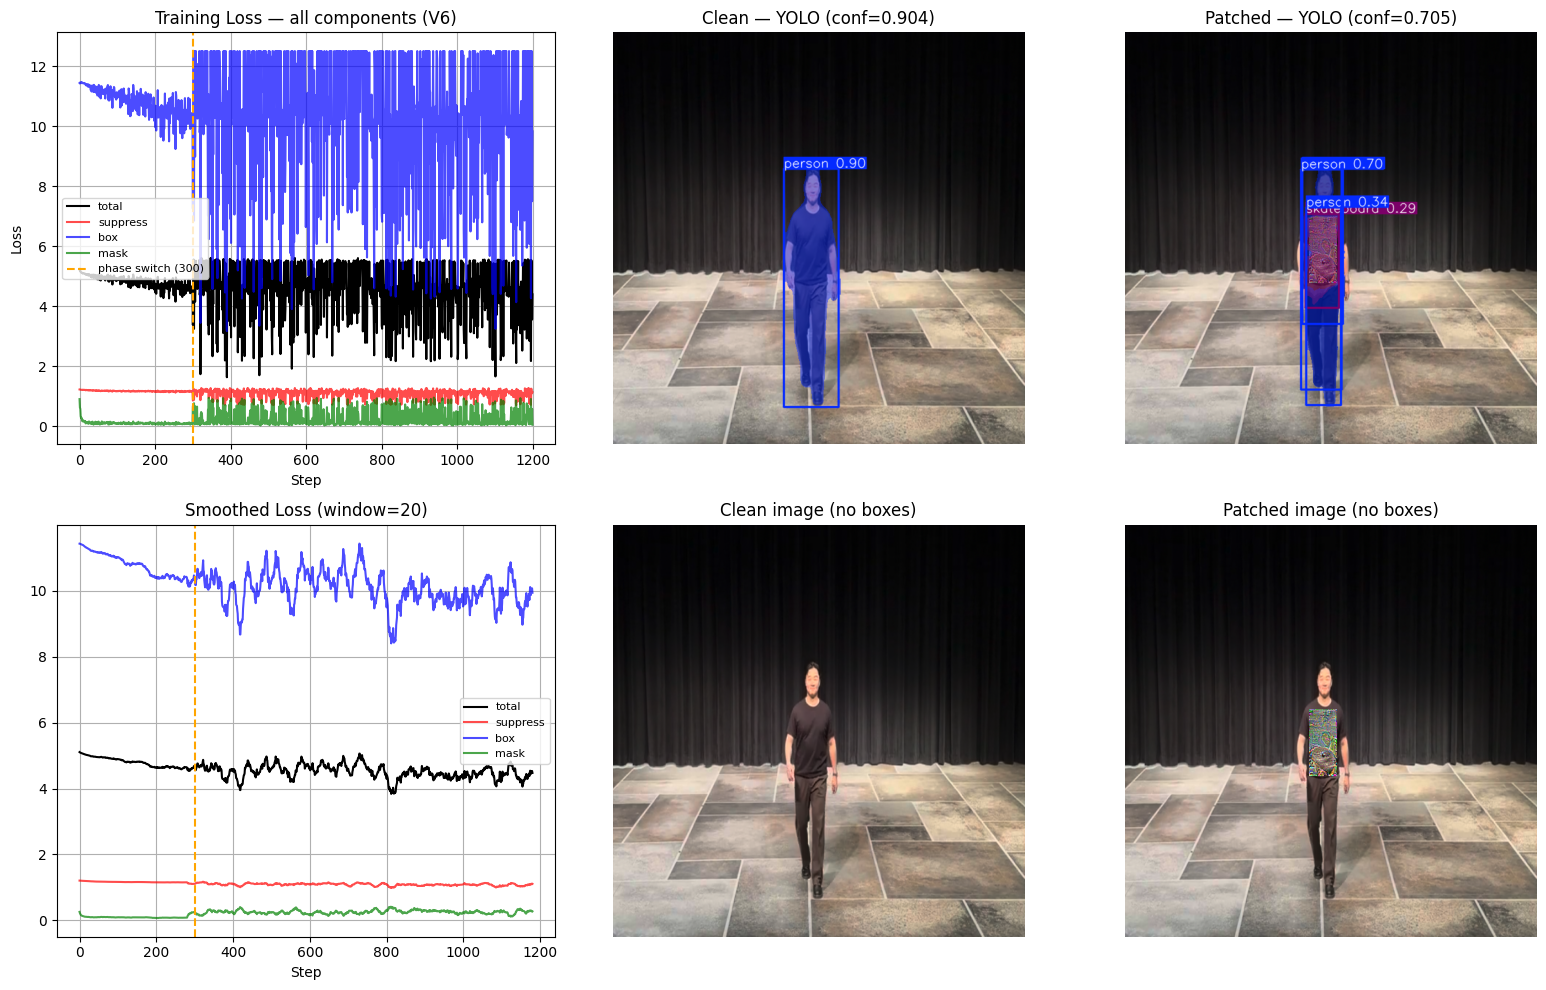

In [14]:
# Cell 13 — Visual evaluation + loss component breakdown
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: loss curves
axes[0, 0].plot(loss_history, label='total', color='black')
axes[0, 0].plot(suppress_history, label='suppress', color='red',   alpha=0.7)
axes[0, 0].plot(box_history,    label='box',      color='blue',  alpha=0.7)
axes[0, 0].plot(mask_history,   label='mask',     color='green', alpha=0.7)
if CURRICULUM_STEPS > 0:
    axes[0, 0].axvline(x=CURRICULUM_STEPS, color='orange', linestyle='--',
                       label=f'phase switch ({CURRICULUM_STEPS})')
axes[0, 0].set_title('Training Loss — all components (V6)')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True)

# Row 1: clean detection
axes[0, 1].imshow(cv2.cvtColor(results_clean_eval[0].plot(), cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f'Clean — YOLO (conf={yolo_clean:.3f})')
axes[0, 1].axis('off')

# Row 1: patched detection
patched_label = f'Patched — YOLO (conf={yolo_patched:.3f})' if yolo_patched else 'Patched — NO DETECTION'
axes[0, 2].imshow(cv2.cvtColor(results_patched_eval[0].plot(), cv2.COLOR_BGR2RGB))
axes[0, 2].set_title(patched_label)
axes[0, 2].axis('off')

# Row 2: smoothed loss (window=20)
window = 20
def smooth(x):
    return np.convolve(x, np.ones(window)/window, mode='valid')

axes[1, 0].plot(smooth(loss_history),   color='black', label='total')
axes[1, 0].plot(smooth(suppress_history), color='red',   label='suppress', alpha=0.7)
axes[1, 0].plot(smooth(box_history),    color='blue',  label='box',      alpha=0.7)
axes[1, 0].plot(smooth(mask_history),   color='green', label='mask',     alpha=0.7)
if CURRICULUM_STEPS > 0:
    axes[1, 0].axvline(x=CURRICULUM_STEPS, color='orange', linestyle='--')
axes[1, 0].set_title(f'Smoothed Loss (window={window})')
axes[1, 0].set_xlabel('Step')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True)

# Row 2: clean image (no overlay)
axes[1, 1].imshow(cv2.cvtColor(img_eval_640, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Clean image (no boxes)')
axes[1, 1].axis('off')

# Row 2: patched image (no overlay) — shows actual patch appearance
axes[1, 2].imshow(cv2.cvtColor(img_patched_np, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title('Patched image (no boxes)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()